In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [199]:
df = pd.read_excel("Team_Stats_By_Week.xlsx", index_col=0)
df.head()

,team_name_full,team_abbr,game_week,pass_completions,pass_attempts,passing_yards,passing_touchdowns,interceptions_thrown,passing_first_downs,times_sacked,...,sack_yards,run_stuffs,interceptions,interception_return_yards,interception_touchdowns,forced_fumbles,fumble_return_touchdowns,passes_defended,safeties,win_loss
index,,,,,,,,,,,,,,,,,,,,,
0,Arizona Cardinals,ARI,1,21.0,29.0,163.0,2.0,0.0,11.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,1
1,Arizona Cardinals,ARI,2,17.0,25.0,220.0,1.0,1.0,10.0,1.0,...,14.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1
2,Arizona Cardinals,ARI,3,22.0,35.0,159.0,1.0,0.0,8.0,1.0,...,0.0,0.0,1.0,18.0,0.0,0.0,0.0,3.0,0.0,0
3,Arizona Cardinals,ARI,4,27.0,41.0,200.0,2.0,2.0,13.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,Arizona Cardinals,ARI,5,23.0,32.0,220.0,0.0,0.0,8.0,3.0,...,16.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,0.0,0


# Exploratory Data Analysis

To get a better understanding of the data, I created a series of visualizations to explore the 
distribution of team statistics. The goal of this analysis is to identify key statistics that could be the most important factors in predicting wins and losses in the NFL.

In [200]:
df.shape

(416, 79)

In [201]:
# filtering for winloss column to be 0 or 1
df = df[df['win_loss'].isin([0, 1])]
df.head()

,team_name_full,team_abbr,game_week,pass_completions,pass_attempts,passing_yards,passing_touchdowns,interceptions_thrown,passing_first_downs,times_sacked,...,sack_yards,run_stuffs,interceptions,interception_return_yards,interception_touchdowns,forced_fumbles,fumble_return_touchdowns,passes_defended,safeties,win_loss
index,,,,,,,,,,,,,,,,,,,,,
0,Arizona Cardinals,ARI,1,21.0,29.0,163.0,2.0,0.0,11.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,1
1,Arizona Cardinals,ARI,2,17.0,25.0,220.0,1.0,1.0,10.0,1.0,...,14.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1
2,Arizona Cardinals,ARI,3,22.0,35.0,159.0,1.0,0.0,8.0,1.0,...,0.0,0.0,1.0,18.0,0.0,0.0,0.0,3.0,0.0,0
3,Arizona Cardinals,ARI,4,27.0,41.0,200.0,2.0,2.0,13.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,Arizona Cardinals,ARI,5,23.0,32.0,220.0,0.0,0.0,8.0,3.0,...,16.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,0.0,0


In [202]:
# checking for na sums greater than 0
df.isna().sum()[df.isna().sum() > 0]

fg_made_(0-19)                          5
fg_attempted_(0-19)                     5
fg_made_(20-29)                         5
fg_attempted_(20-29)                    5
fg_made_(30-39)                         5
fg_attempted_(30-39)                    5
fg_made_(40-49)                         5
fg_attempted_(40-49)                    5
fg_made_(50+)                           5
fg_attempted_(50+)                      5
fg_made_(total)                         5
fg_attempted_(total)                    5
extra_points_made                       5
extra_points_attempted                  5
kickoffs                                5
kickoff_yards                           5
kickoff_fair_catches                    5
touchbacks                              5
kick_returns_allowed                    5
kick_return_touchdowns_allowed          5
kick_return_yards_allowed_per_return    5
punts                                   7
punt_yards                              7
punts_inside_20                   

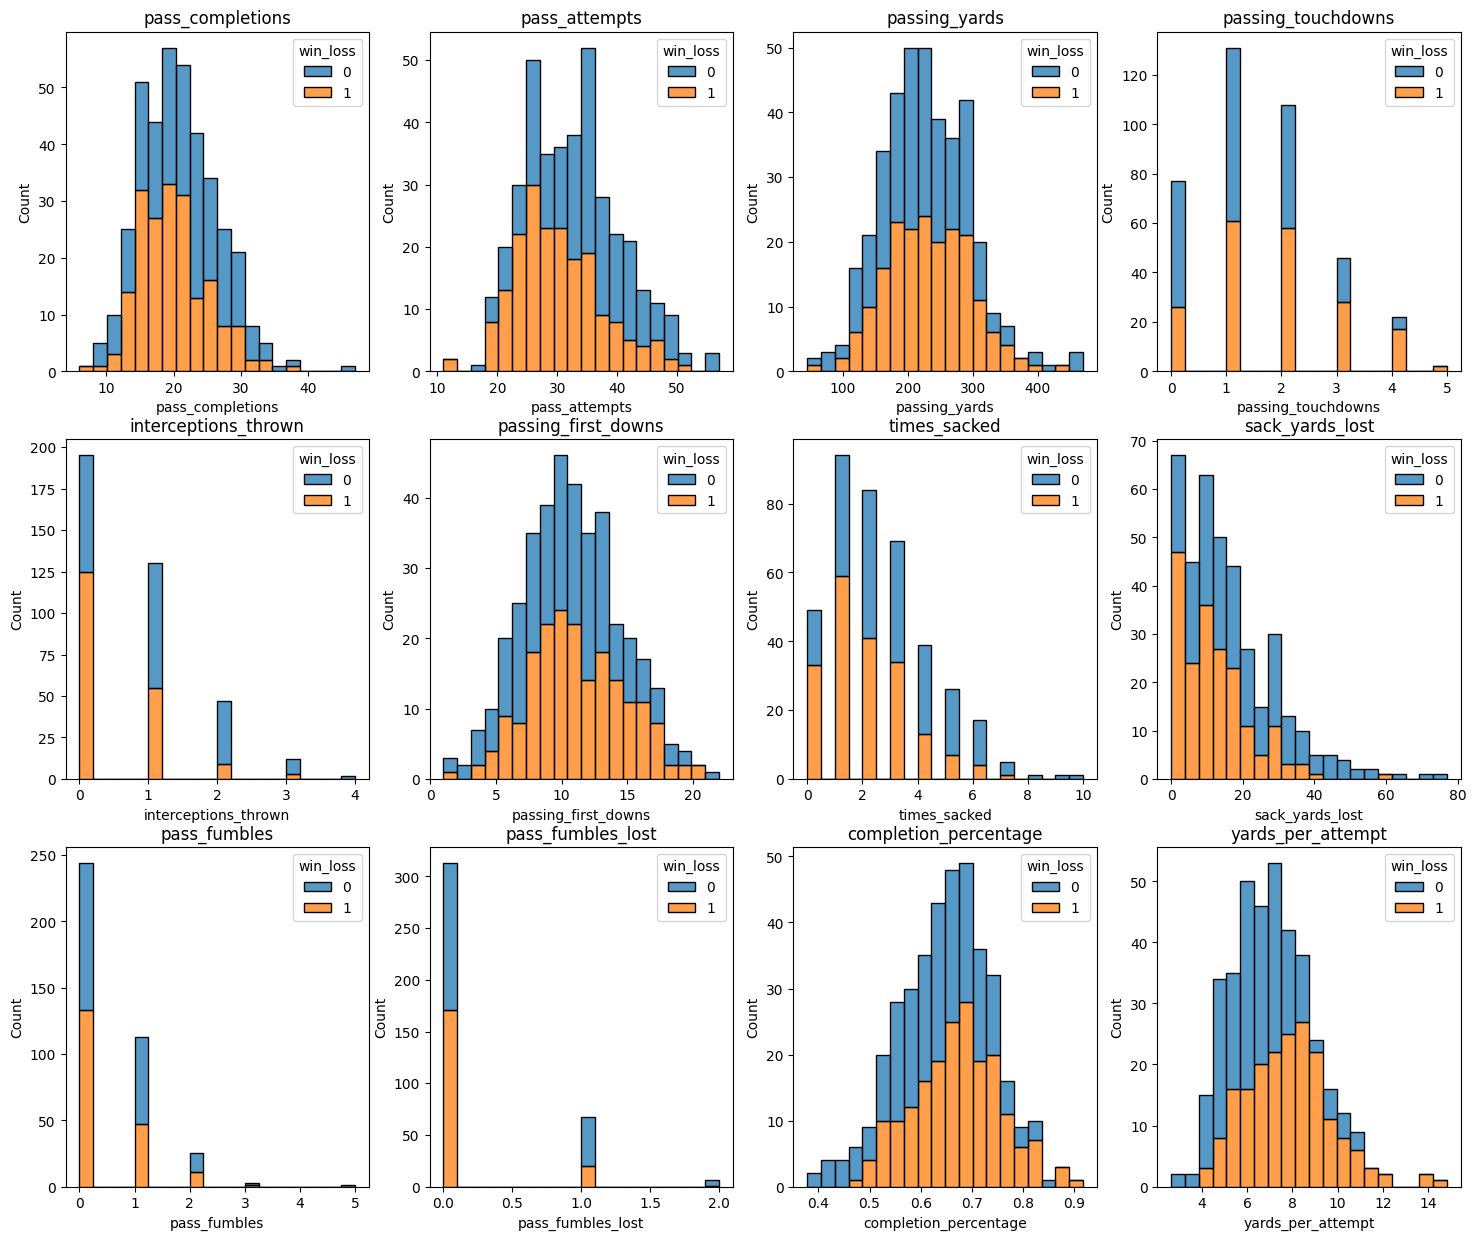

In [119]:
# plotting passing columns
passing_cols = ["pass_completions",
    "pass_attempts",
    "passing_yards",
    "passing_touchdowns",
    "interceptions_thrown",
    "passing_first_downs",
    "times_sacked",
    "sack_yards_lost",
    "pass_fumbles",
    "pass_fumbles_lost",
    "completion_percentage",
    "yards_per_attempt"]

fig, axes = plt.subplots(3, 4, figsize=(18, 15))
for i in range(len(passing_cols)):
    ax = axes[i // 4, i % 4]
    sns.histplot(data=df, x=passing_cols[i], bins=20, ax=ax, hue='win_loss', multiple='stack')
    ax.set_title(passing_cols[i])
plt.show();


- passing_touchdowns: The first thing I noticed was the proportion of win to loss favored the loss class for lower values and the win class for higher values of passing touchdowns.
- interceptions_thrown: The number of interceptions thrown increases the proportion of the loss class increases.  
- times_sacked & sack_yards_lost: The main thing I noticed was that the 
loss class maximum values are higher than the win class and that the tail for the loss class 
is much longer than the win class.
- completion_percentage: Notice there are very few win occurrences below .5 and very few loss occurrences above .8. 
- yards_per_attempt: The loss class is slightly skewed right distributed around 7 yards per attempt while the win class is more normally distributed around 8.5 yards per attempt.

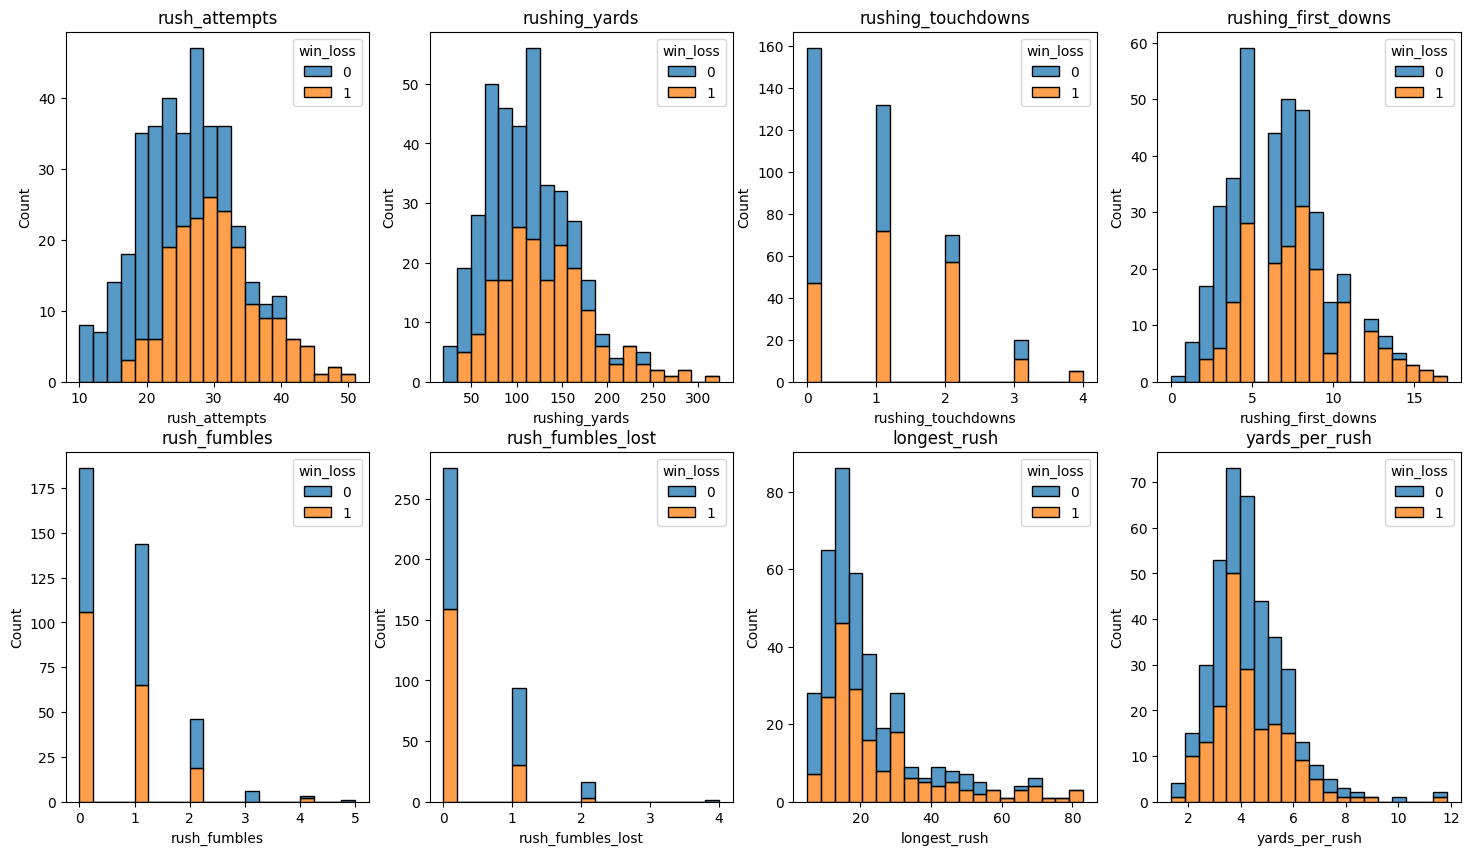

In [120]:
# plotting rushing columns
rushing_cols = ["rush_attempts",
    "rushing_yards",
    "rushing_touchdowns",
    "rushing_first_downs",
    "rush_fumbles",
    "rush_fumbles_lost",
    "longest_rush",
    "yards_per_rush"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for i in range(len(rushing_cols)):
    ax = axes[i // 4, i % 4]
    sns.histplot(data=df, x=rushing_cols[i], bins=20, ax=ax, hue='win_loss', multiple='stack')
    ax.set_title(rushing_cols[i])
plt.show();

- rush_attempts:  The shape is similar to the completion percentages chart showing the win class is distributed around 30 attempts whereas the loss class is distributed around 25 attempts with very few over 32.


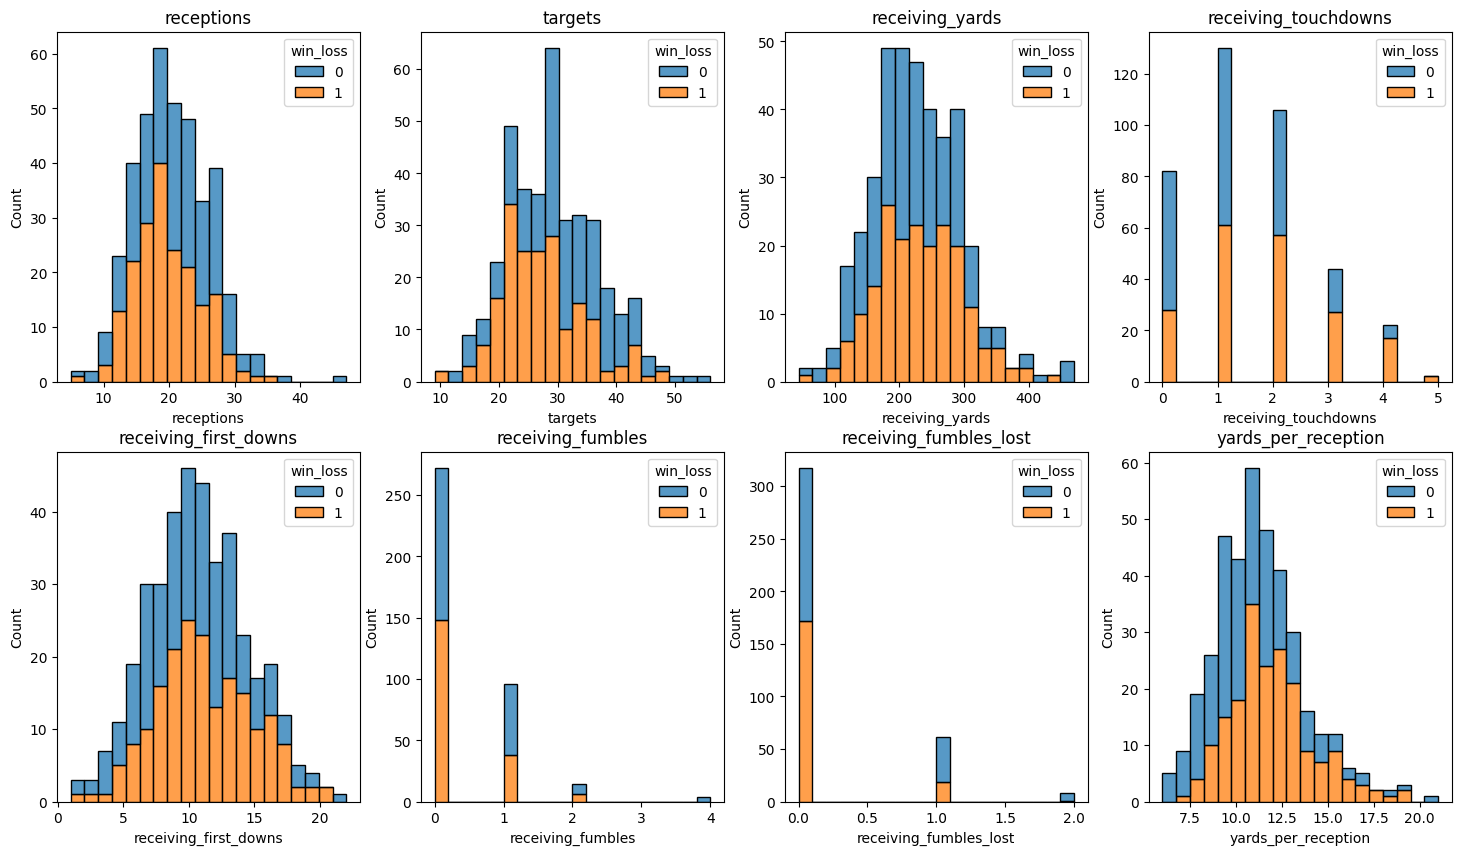

In [121]:
# plotting recieving columns
recieving_cols = ["receptions",
    "targets",
    "receiving_yards",
    "receiving_touchdowns",
    "receiving_first_downs",
    "receiving_fumbles",
    "receiving_fumbles_lost",
    "yards_per_reception"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for i in range(len(recieving_cols)):
    ax = axes[i // 4, i % 4]
    sns.histplot(data=df, x=recieving_cols[i], bins=20, ax=ax, hue='win_loss', multiple='stack')
    ax.set_title(recieving_cols[i])
plt.show();

- yards_per_reception:  The lower yards per reception show more losses while the higher yards per 
reception have more wins.
- yards_per_reception: Both classes show similar distributions except for on the tails. The lower yards per reception show more losses while the higher yards per reception have more wins. 

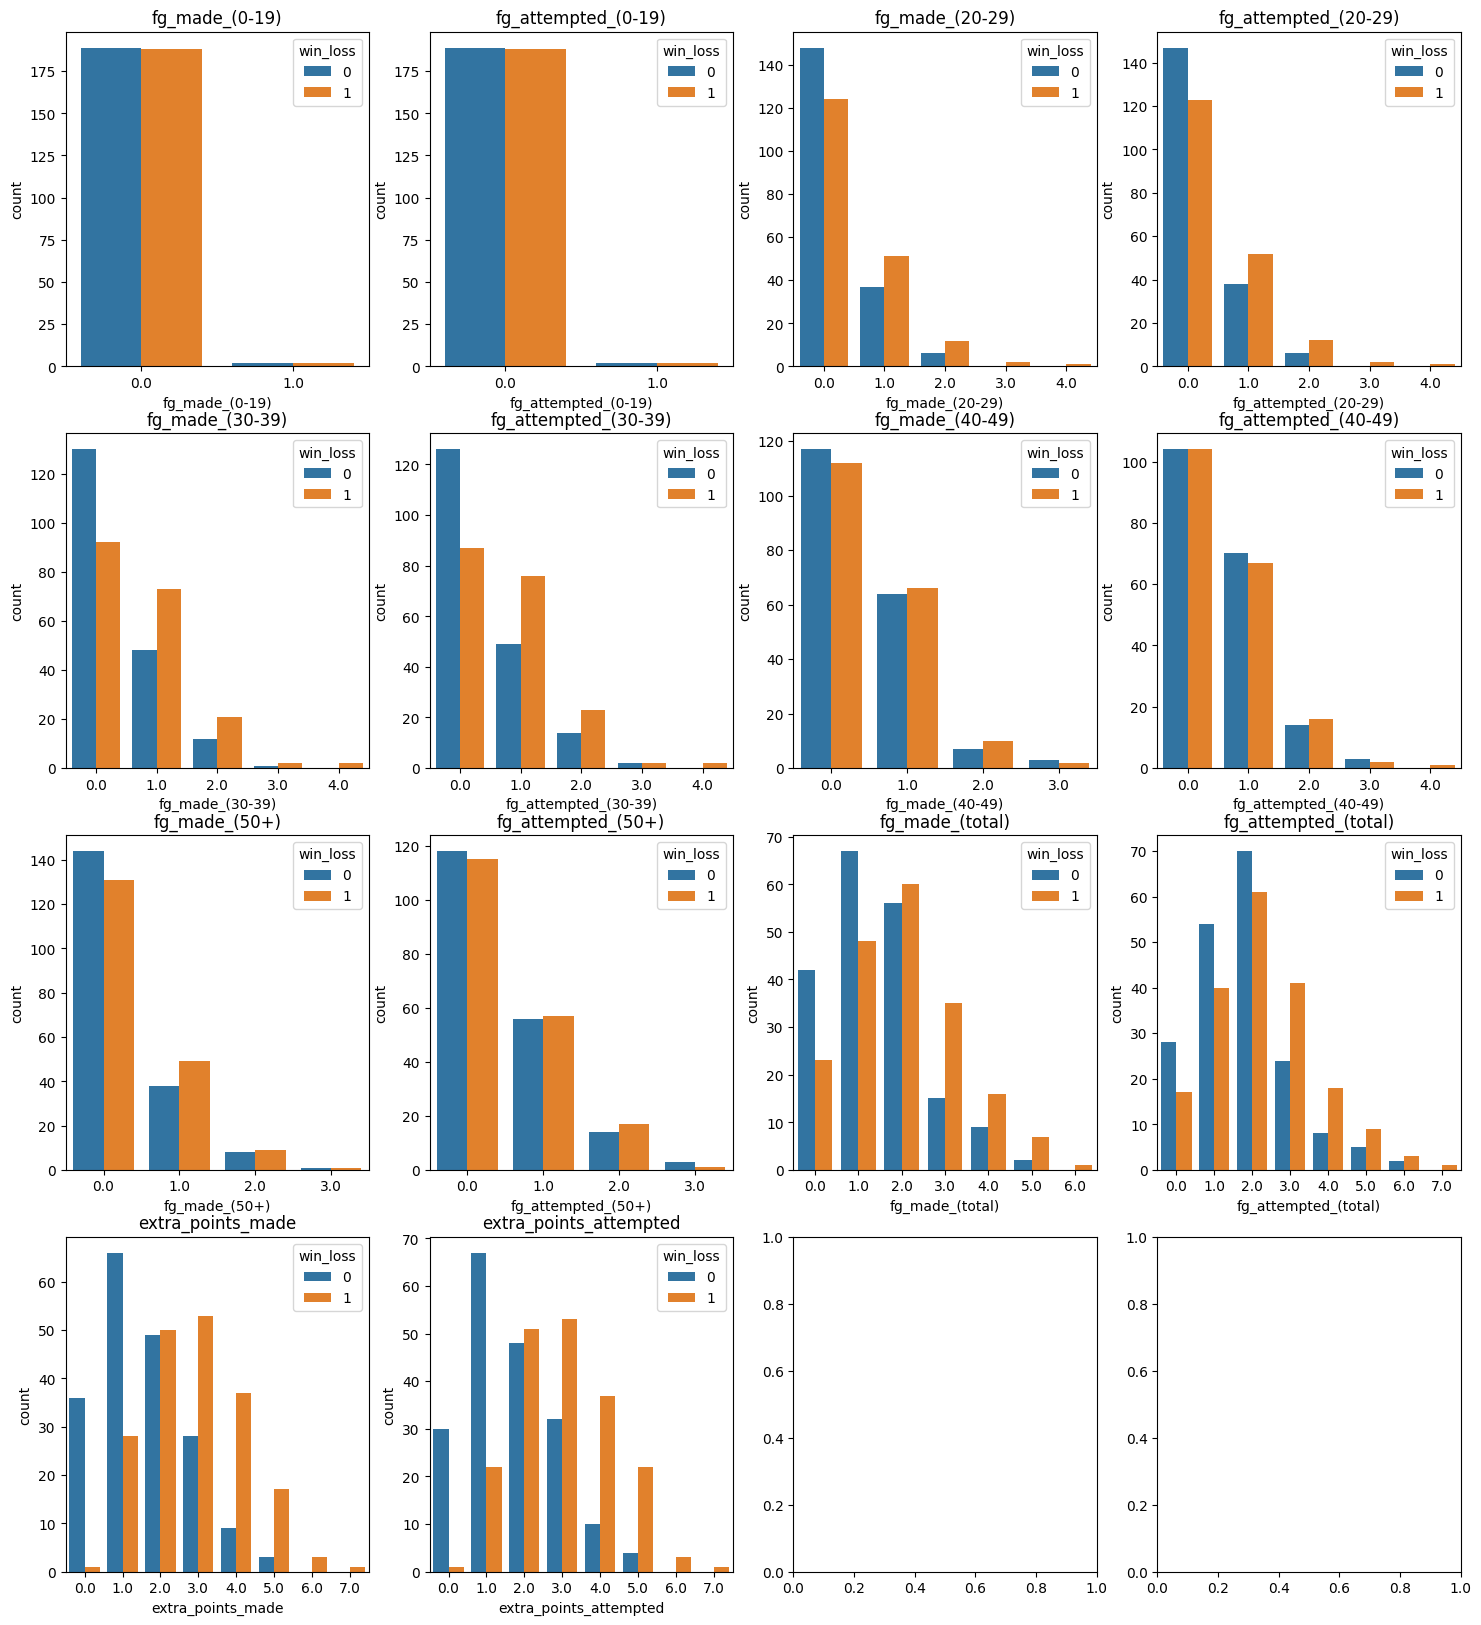

In [122]:
# plotting kicking columns
kicking_cols = ["fg_made_(0-19)",
    "fg_attempted_(0-19)",
    "fg_made_(20-29)",
    "fg_attempted_(20-29)",
    "fg_made_(30-39)",
    "fg_attempted_(30-39)",
    "fg_made_(40-49)",
    "fg_attempted_(40-49)",
    "fg_made_(50+)",
    "fg_attempted_(50+)",
    "fg_made_(total)",
    "fg_attempted_(total)",
    "extra_points_made",
    "extra_points_attempted"]

fig, axes = plt.subplots(4, 4, figsize=(18, 20))
for i in range(len(kicking_cols)):
    ax = axes[i // 4, i % 4]
    sns.countplot(data=df, x=kicking_cols[i], ax=ax, hue='win_loss')
    ax.set_title(kicking_cols[i])
plt.show();

- fg_made_(total) & fg_attempted_(total): The main thing I noticed was is the loss class is more prevalent for one field goals made and lower and two field goals attempted and lower. Anything above that the win classes are more prevalent.
- extra_points_made & extra_points_attempted: These charts show extra points made and extra points attempted similarly to the field goals made and attempted the loss class is vastly more prevalent for extra points made and attempted one and below.


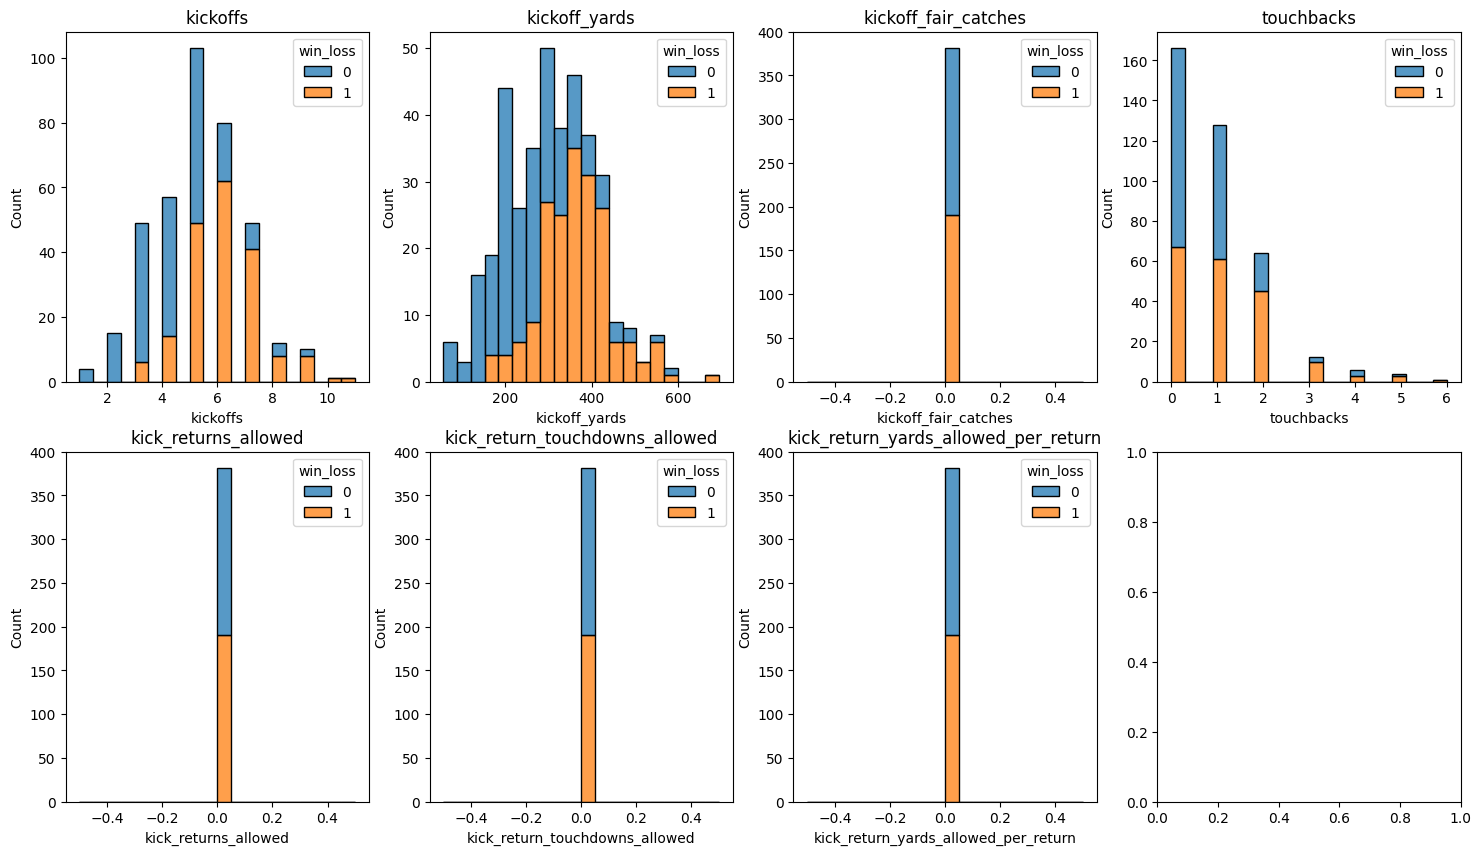

In [123]:
# plotting kickoff columns
kickoff_cols = ["kickoffs",
    "kickoff_yards",
    "kickoff_fair_catches",
    "touchbacks",
    "kick_returns_allowed",
    "kick_return_touchdowns_allowed",
    "kick_return_yards_allowed_per_return"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for i in range(len(kickoff_cols)):
    ax = axes[i // 4, i % 4]
    sns.histplot(data=df, x=kickoff_cols[i], bins=20, ax=ax, hue='win_loss', multiple='stack')
    ax.set_title(kickoff_cols[i])
plt.show();

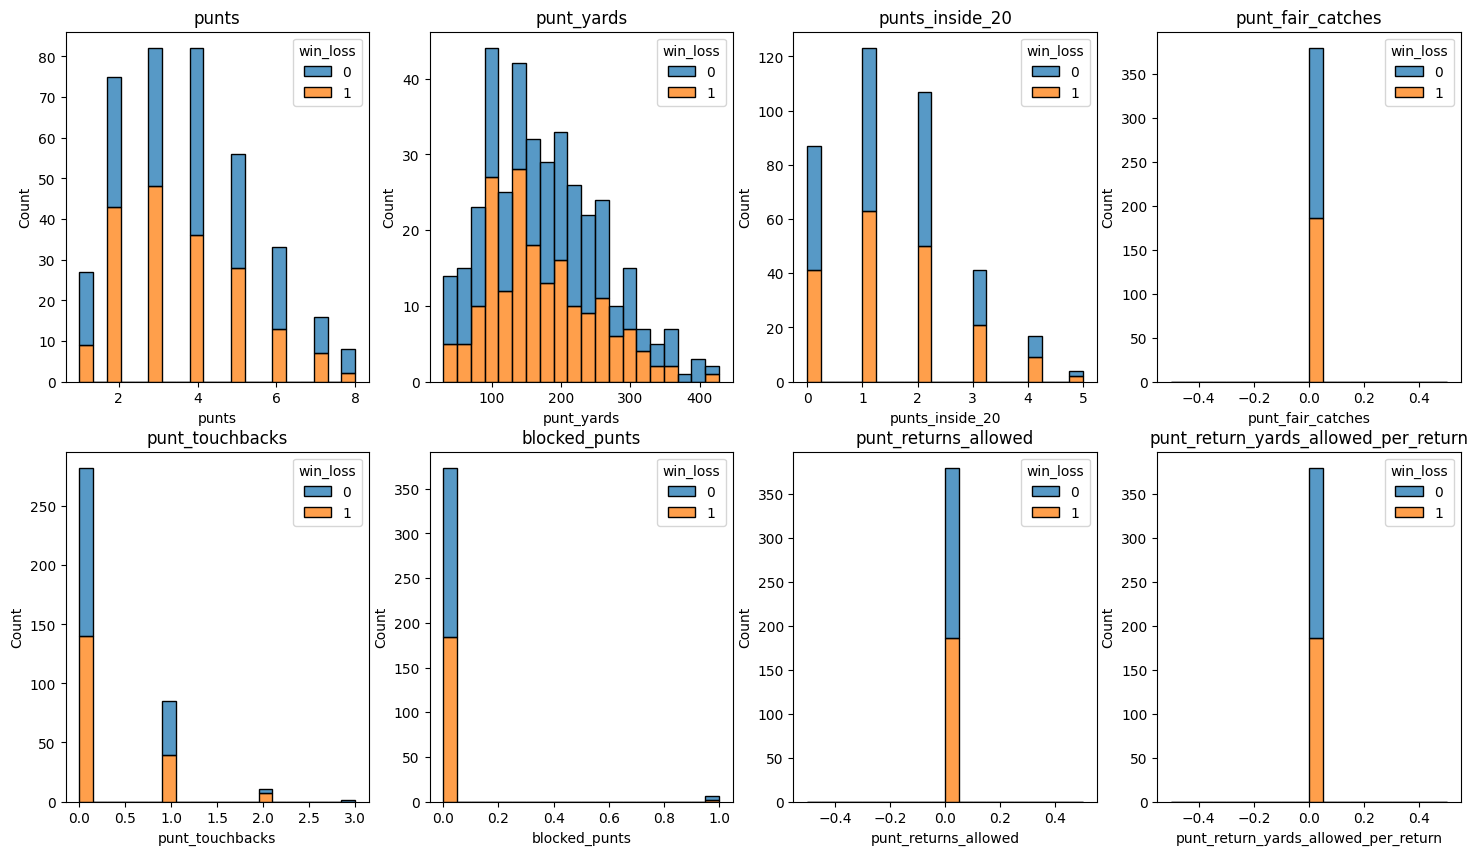

In [124]:
# plotting punting columns
punting_cols = ["punts",
    "punt_yards",
    "punts_inside_20",
    "punt_fair_catches",
    "punt_touchbacks",
    "blocked_punts",
    "punt_returns_allowed",
    "punt_return_yards_allowed_per_return"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for i in range(len(punting_cols)):
    ax = axes[i // 4, i % 4]
    sns.histplot(data=df, x=punting_cols[i], bins=20, ax=ax, hue='win_loss', multiple='stack')
    ax.set_title(punting_cols[i])
plt.show();

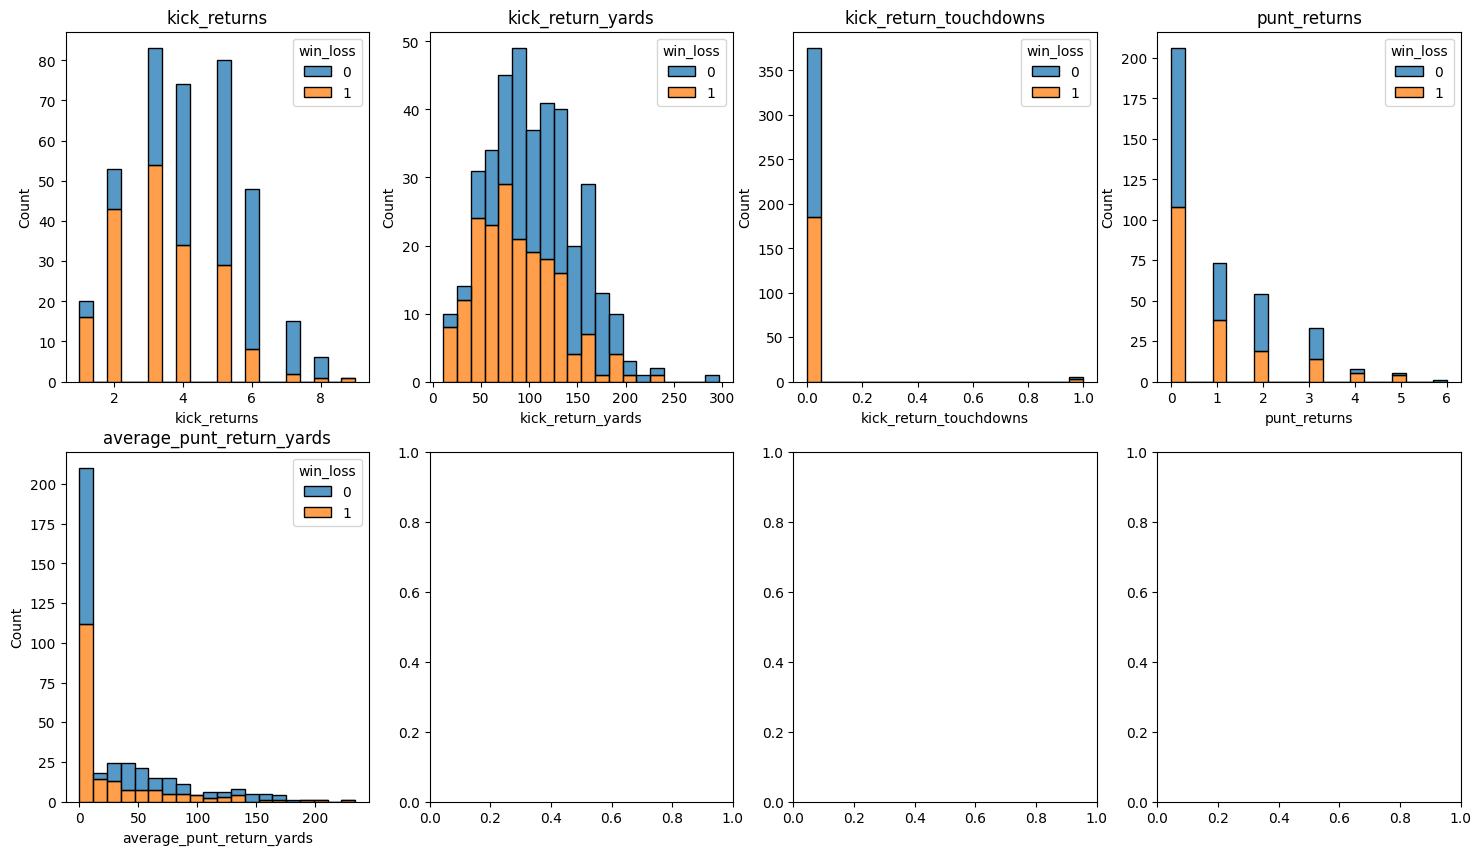

In [125]:
# plotting return columns
return_cols = ["kick_returns",
    "kick_return_yards",
    "kick_return_touchdowns",
    "punt_returns",
    "average_punt_return_yards"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for i in range(len(return_cols)):
    ax = axes[i // 4, i % 4]
    sns.histplot(data=df, x=return_cols[i], bins=20, ax=ax, hue='win_loss', multiple='stack')
    ax.set_title(return_cols[i])
plt.show();

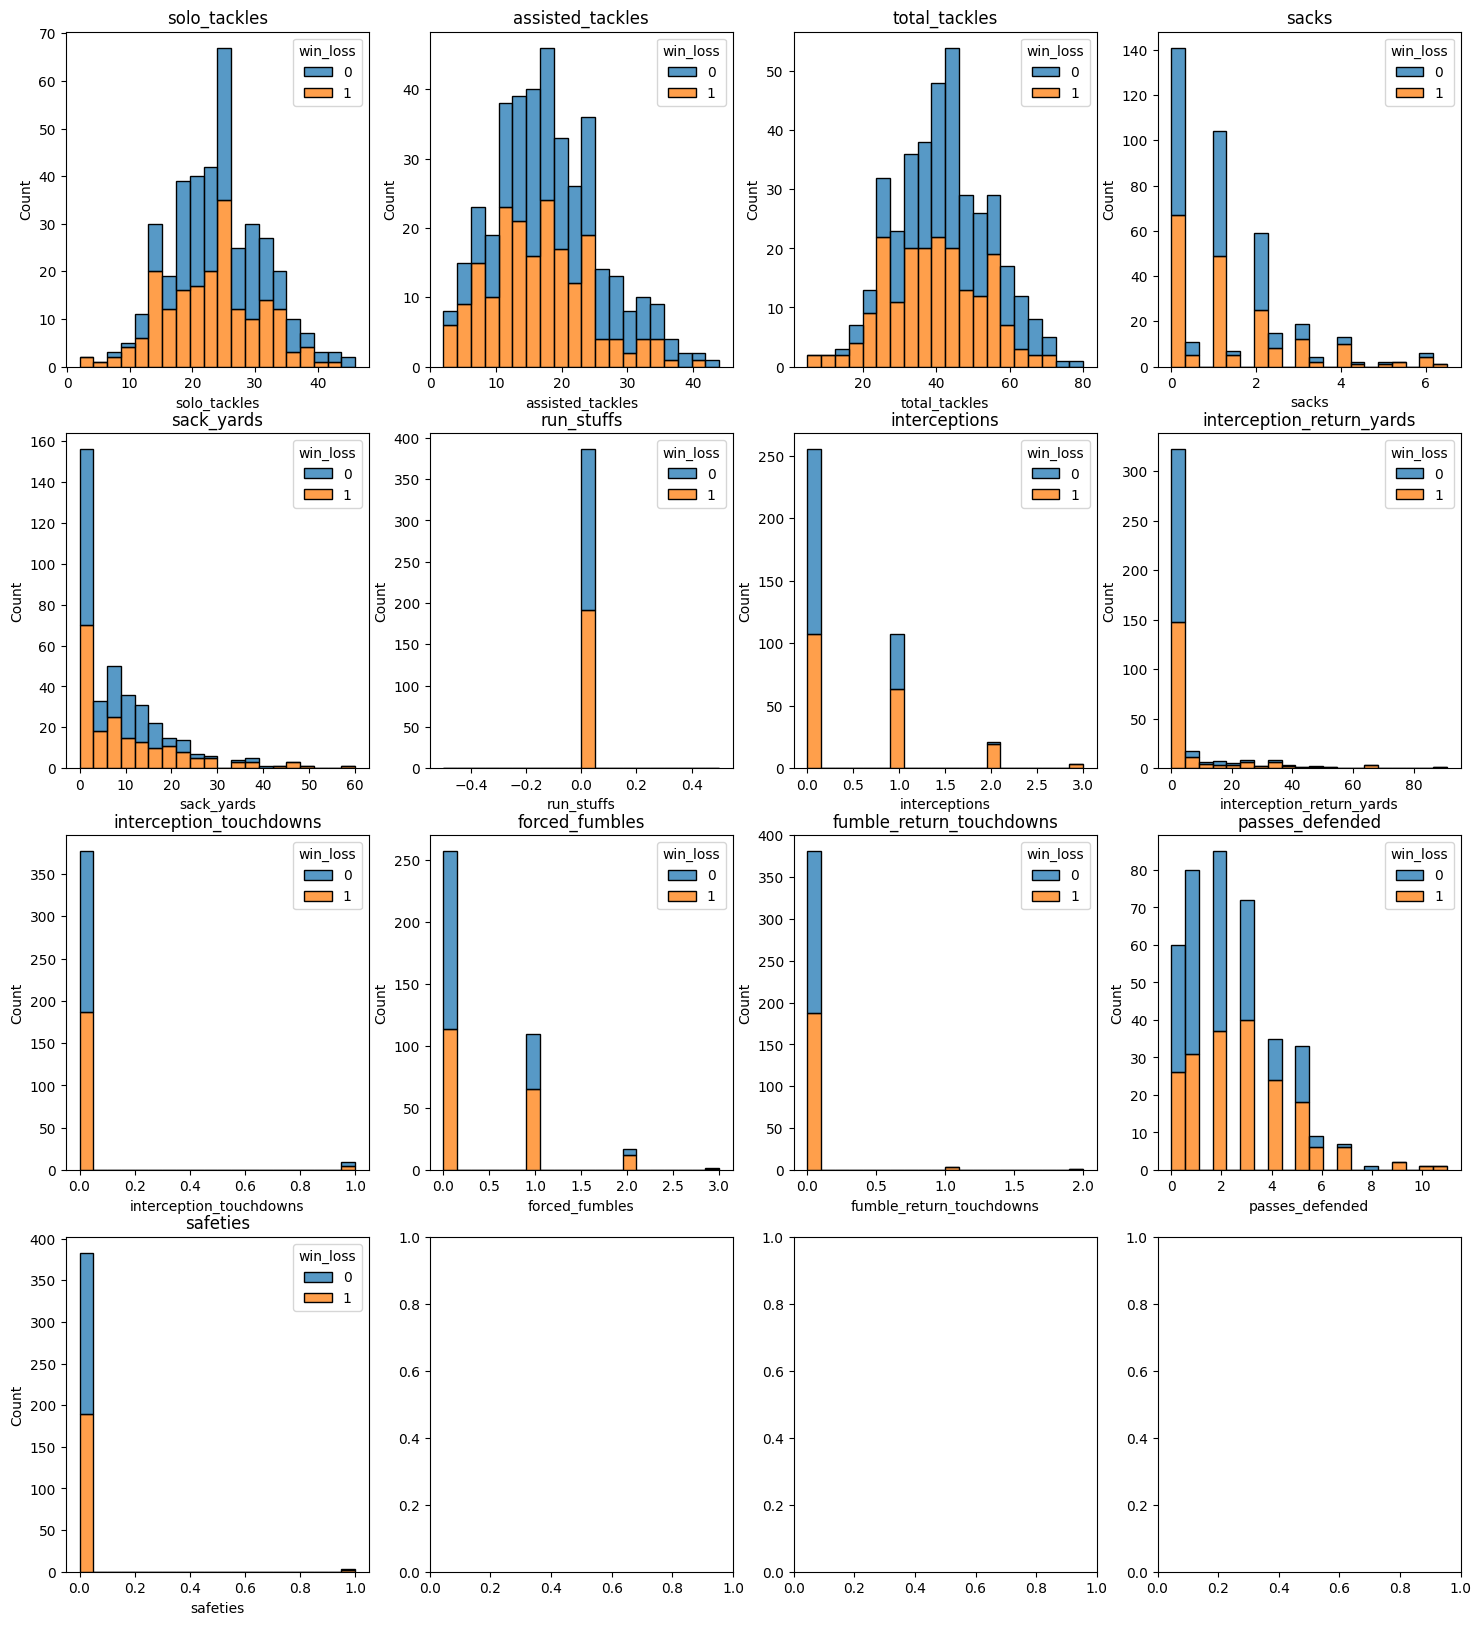

In [126]:
# plotting defense columns
defense_cols = ["solo_tackles",
    "assisted_tackles",
    "total_tackles",
    "sacks",
    "sack_yards",
    "run_stuffs",
    "interceptions",
    "interception_return_yards",
    "interception_touchdowns",
    "forced_fumbles",
    "fumble_return_touchdowns",
    "passes_defended",
    "safeties"]

fig, axes = plt.subplots(4, 4, figsize=(18, 20))
for i in range(len(defense_cols)):
    ax = axes[i // 4, i % 4]
    sns.histplot(data=df, x=defense_cols[i], bins=20, ax=ax, hue='win_loss', multiple='stack')
    ax.set_title(defense_cols[i])
plt.show();

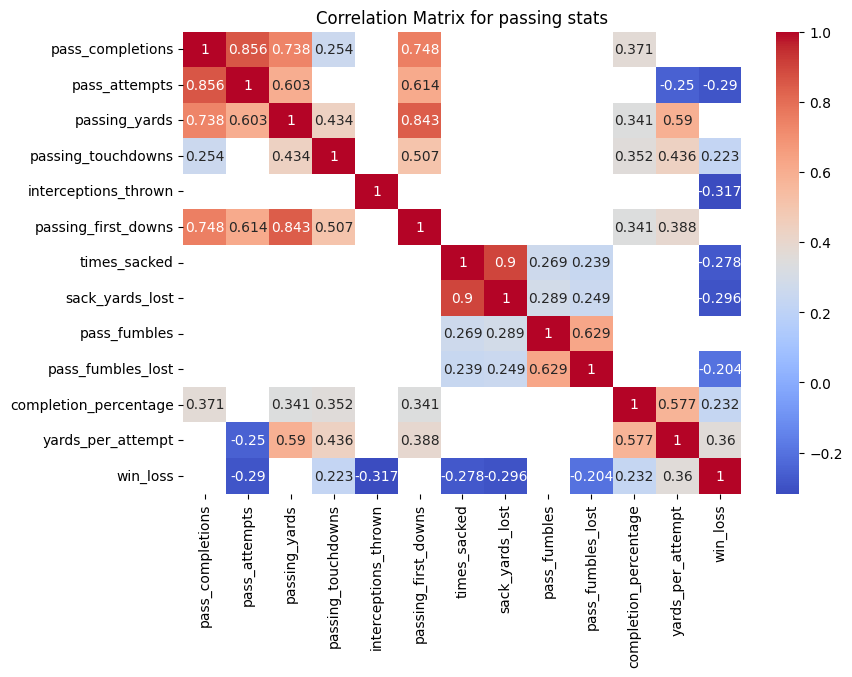

In [127]:
# heatmap of passing columns with correlation to win_loss
df_passing = df[passing_cols + ['win_loss']]

plt.figure(figsize = (9, 6))

corr_matrix_train = df_passing.corr(numeric_only=True)
corr_filtered_train = corr_matrix_train[np.abs(corr_matrix_train) > 0.2]
# Create a heatmap
sns.heatmap(corr_filtered_train, cmap='coolwarm', annot = True, fmt='.3g')
plt.title('Correlation Matrix for passing stats')
plt.show();

The above chart shows the heatmap for the passing statistics. From this we can see a lot of 
high correlation values. A lot of these make sense as the more sacks you have it would 
make sense that you would have more sack yards lost.  

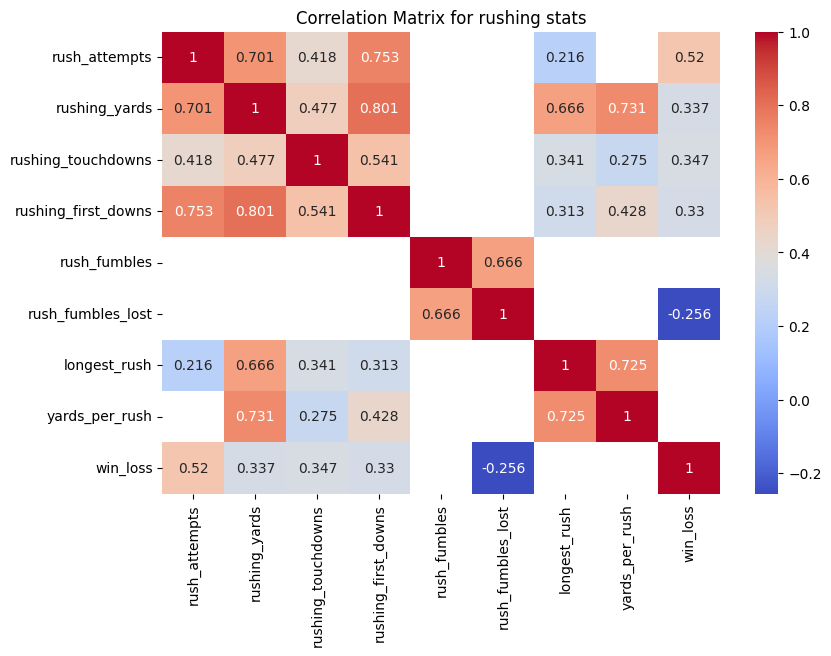

In [128]:
# heatmap of rushing columns with correlation to win_loss
df_rushing = df[rushing_cols + ['win_loss']]

plt.figure(figsize = (9, 6))

corr_matrix_train = df_rushing.corr(numeric_only=True)
corr_filtered_train = corr_matrix_train[np.abs(corr_matrix_train) > 0.2]
# Create a heatmap
sns.heatmap(corr_filtered_train, cmap='coolwarm', annot = True, fmt='.3g')
plt.title('Correlation Matrix for rushing stats')
plt.show();

The above chart shows the heatmap for the rushing statistics. From this we can see a lot of 
high correlation values. Similarly to the passing heatmap, the high correlation makes 
sense. These are things that I will need to keep in mind during the modeling process so I 
can avoid multicollinearity.  

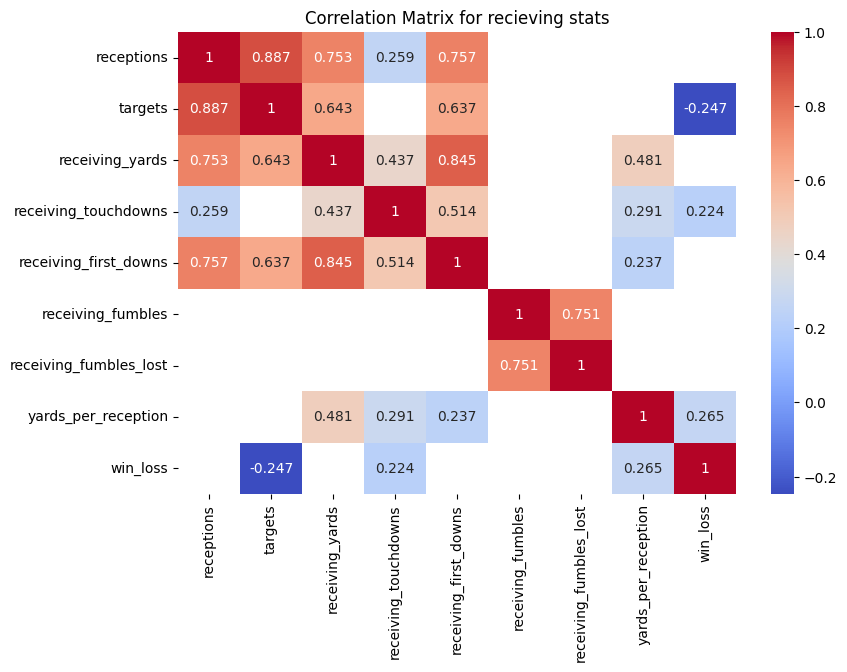

In [129]:
# heatmap of recieving columns with correlation to win_loss
df_recieving = df[recieving_cols + ['win_loss']]

plt.figure(figsize = (9, 6))

corr_matrix_train = df_recieving.corr(numeric_only=True)
corr_filtered_train = corr_matrix_train[np.abs(corr_matrix_train) > 0.2]
# Create a heatmap
sns.heatmap(corr_filtered_train, cmap='coolwarm', annot = True, fmt='.3g')
plt.title('Correlation Matrix for recieving stats')
plt.show();

The above chart shows the heatmap for the receiving statistics. From this we can see a lot 
of high correlation values specifically with the receptions, targets, and first downs 
columns.  

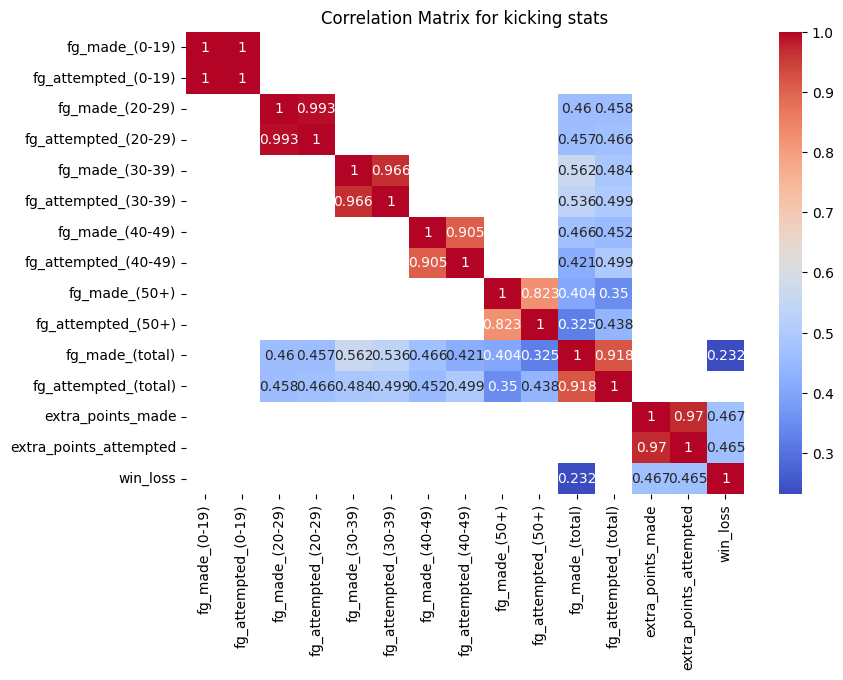

In [130]:
# heatmap of kicking columns with correlation to win_loss
df_kicking = df[kicking_cols + ['win_loss']]

plt.figure(figsize = (9, 6))

corr_matrix_train = df_kicking.corr(numeric_only=True)
corr_filtered_train = corr_matrix_train[np.abs(corr_matrix_train) > 0.2]
# Create a heatmap
sns.heatmap(corr_filtered_train, cmap='coolwarm', annot = True, fmt='.3g')
plt.title('Correlation Matrix for kicking stats')
plt.show();

The above chart shows the heatmap for the kicking statistics. From this we can see a lot of 
high correlation values. Since there is a column for field goals made and attempted, these 
are going to be very highly correlated since most kickers have a remarkably high make 
percentage. For modeling it would be smart to engineer a new feature from these or choose 
one or the other to include in the model.  

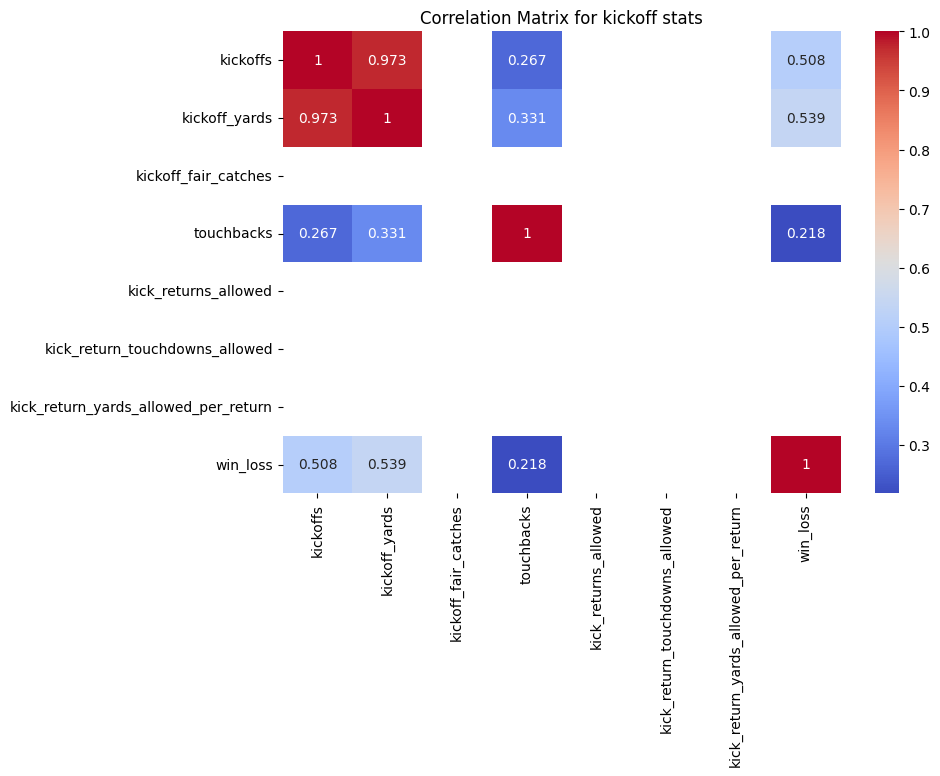

In [131]:
# heatmap of kickoff columns with correlation to win_loss
df_kickoff = df[kickoff_cols + ['win_loss']]

plt.figure(figsize = (9, 6))

corr_matrix_train = df_kickoff.corr(numeric_only=True)
corr_filtered_train = corr_matrix_train[np.abs(corr_matrix_train) > 0.2]
# Create a heatmap
sns.heatmap(corr_filtered_train, cmap='coolwarm', annot = True, fmt='.3g')
plt.title('Correlation Matrix for kickoff stats')
plt.show();

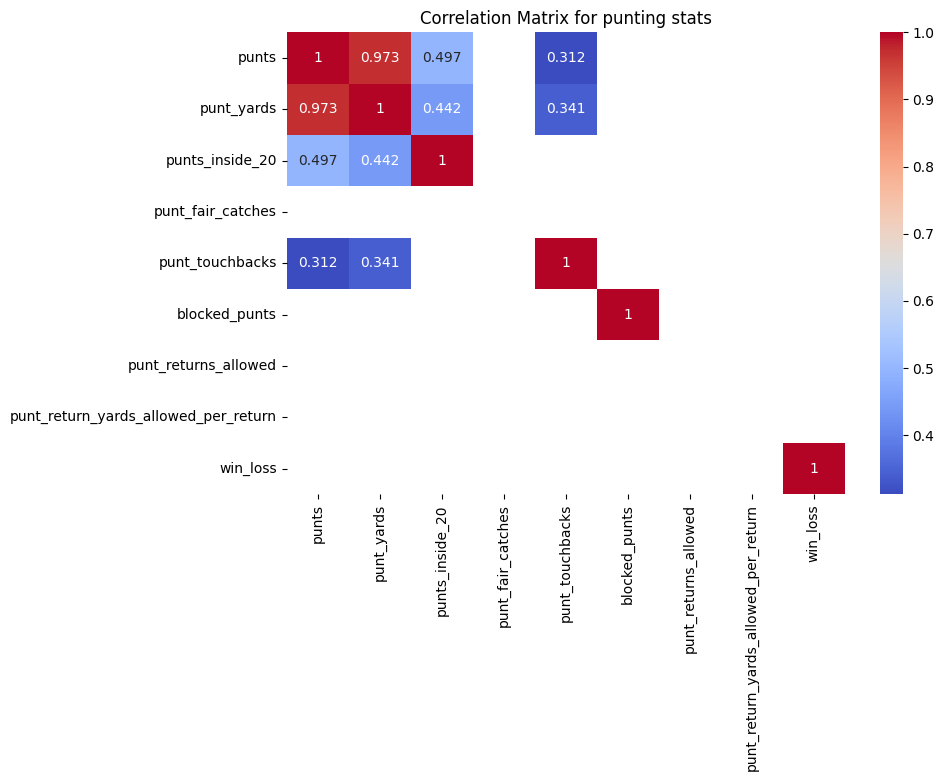

In [132]:
# heatmap of punting columns with correlation to win_loss
df_punting = df[punting_cols + ['win_loss']]

plt.figure(figsize = (9, 6))

corr_matrix_train = df_punting.corr(numeric_only=True)
corr_filtered_train = corr_matrix_train[np.abs(corr_matrix_train) > 0.2]
# Create a heatmap
sns.heatmap(corr_filtered_train, cmap='coolwarm', annot = True, fmt='.3g')
plt.title('Correlation Matrix for punting stats')
plt.show();

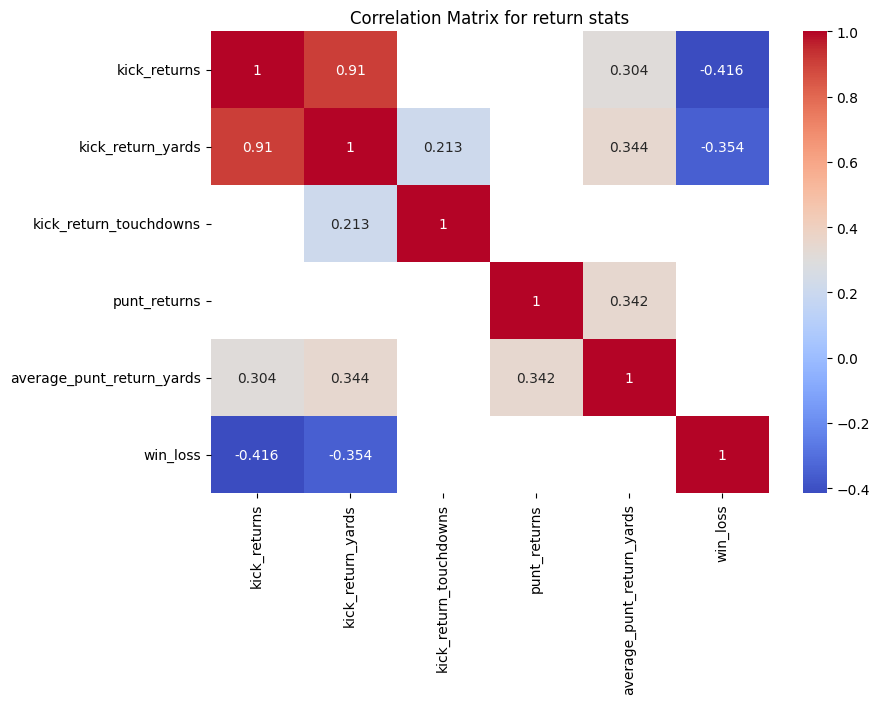

In [133]:
# heatmap of return columns with correlation to win_loss
df_return = df[return_cols + ['win_loss']]

plt.figure(figsize = (9, 6))

corr_matrix_train = df_return.corr(numeric_only=True)
corr_filtered_train = corr_matrix_train[np.abs(corr_matrix_train) > 0.2]
# Create a heatmap
sns.heatmap(corr_filtered_train, cmap='coolwarm', annot = True, fmt='.3g')
plt.title('Correlation Matrix for return stats')
plt.show();

The above chart shows the heatmap for the return statistics. From this we can see a few 
high correlation values specifically between kick return yards and kick returns. 

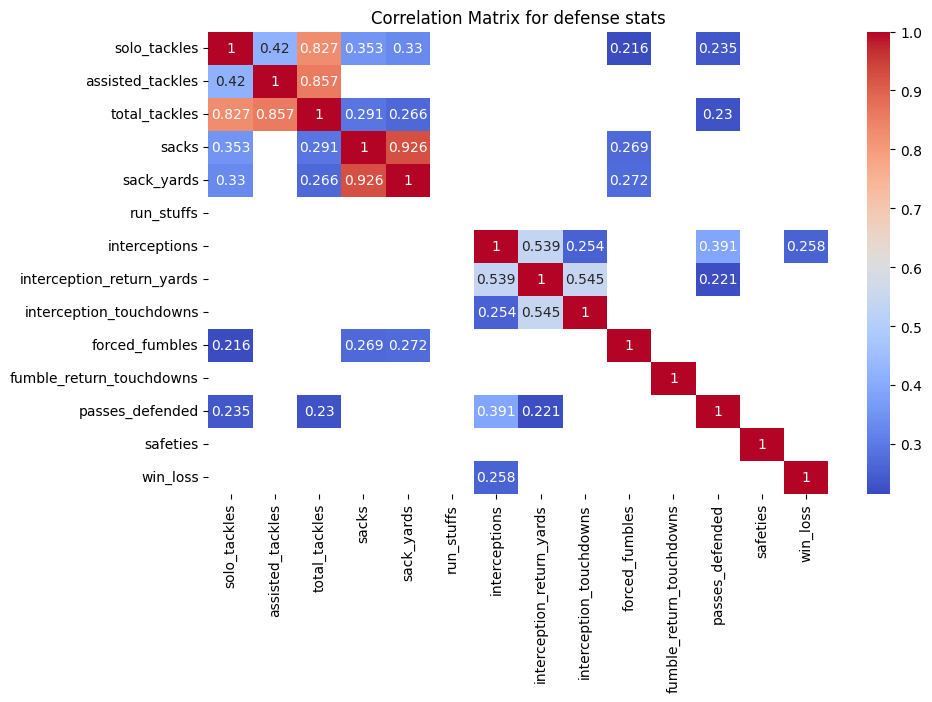

In [134]:
# heatmap of return columns with correlation to win_loss
df_defense = df[defense_cols + ['win_loss']]

plt.figure(figsize = (10, 6))

corr_matrix_train = df_defense.corr(numeric_only=True)
corr_filtered_train = corr_matrix_train[np.abs(corr_matrix_train) > 0.2]
# Create a heatmap
sns.heatmap(corr_filtered_train, cmap='coolwarm', annot = True, fmt='.3g')
plt.title('Correlation Matrix for defense stats')
plt.show();

The above chart shows the heatmap for the defense statistics. From this we can see a lot of 
high correlation values specifically in the sacks and tackles columns.  

In [135]:
# filling na values with column with 0
df = df.fillna(0)
df.head()

,team_name_full,team_abbr,game_week,pass_completions,pass_attempts,passing_yards,passing_touchdowns,interceptions_thrown,passing_first_downs,times_sacked,...,sack_yards,run_stuffs,interceptions,interception_return_yards,interception_touchdowns,forced_fumbles,fumble_return_touchdowns,passes_defended,safeties,win_loss
index,,,,,,,,,,,,,,,,,,,,,
0,Arizona Cardinals,ARI,1,21.0,29.0,163.0,2.0,0.0,11.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,1
1,Arizona Cardinals,ARI,2,17.0,25.0,220.0,1.0,1.0,10.0,1.0,...,14.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1
2,Arizona Cardinals,ARI,3,22.0,35.0,159.0,1.0,0.0,8.0,1.0,...,0.0,0.0,1.0,18.0,0.0,0.0,0.0,3.0,0.0,0
3,Arizona Cardinals,ARI,4,27.0,41.0,200.0,2.0,2.0,13.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,Arizona Cardinals,ARI,5,23.0,32.0,220.0,0.0,0.0,8.0,3.0,...,16.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,0.0,0


# Modeling

Now that I have familiarized myself with the data and taken notice of high correlation 
features with the predictors and with the target variable, I feel comfortable starting the 
modeling process. There were missing values in this dataset so to resolve this I filled them 
with 0. I decided to do this because for a lot of these missing values the event simply did 
not occur. For example, if no field goals were attempted from 50+ yards the field would be 
left empty.  
This dataset has a lot of columns so instead of building a model on the entire dataset I 
decided to build a logistic regression model on each of the statistics groups e.g. One on the 
passing columns, one on the rush columns, and so on. After running each model, I would 
add significant columns to a list to use in my final model. The results of each model can be 
found below.

In [148]:
import statsmodels.api as sm

# setting up Logit regression model
X = df[passing_cols]
y = df['win_loss']

X = sm.add_constant(X)  # adding a constant
model = sm.Logit(y, X).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.497266
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               win_loss   No. Observations:                  386
Model:                          Logit   Df Residuals:                      373
Method:                           MLE   Df Model:                           12
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2826
Time:                        17:34:50   Log-Likelihood:                -191.94
converged:                       True   LL-Null:                       -267.55
Covariance Type:            nonrobust   LLR p-value:                 3.221e-26
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.9969      4.219     -0.236      0.813      -9.266       7.273
pass_completions         -0.1830      0.246     -0.743      0.457      -0.666       0.300
pass_attempts            -0.0099      0.131     -0.075      0.940      -0.266       0.247
passing_yards            -0.0045      0.012     -0.372      0.710      -0.028       0.019
passing_touchdowns       -0.0305      0.139     -0.219      0.827      -0.303       0.242
interceptions_thrown     -0.7151      0.169     -4.228      0.000      -1.047      -0.384
passing_first_downs       0.2911      0.081      3.597      0.000       0.132       0.450
times_sacked             -0.0848      0.166     -0.512      0.609      -0.409       0.240
sack_yards_lost          -0.0326      0.024     -1.370      0.171      -0.079       0.014
pass_fumbles              0.3221      0.242      1.330      0.183      -0.153       0.797
pass_fumbles_lost        -1.2281      0.406     -3.027      0.002      -2.023      -0.433
completion_percentage     3.8204      7.913      0.483      0.629     -11.689      19.330
yards_per_attempt         0.2538      0.361      0.704      0.482      -0.453       0.961
=========================================================================================
"""

In [149]:
significant_cols = model.pvalues[model.pvalues < 0.05].index.tolist()

In [150]:
# setting up Logit regression model
X = df[rushing_cols]
y = df['win_loss']

X = sm.add_constant(X)  # adding a constant
model = sm.Logit(y, X).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.469836
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               win_loss   No. Observations:                  386
Model:                          Logit   Df Residuals:                      377
Method:                           MLE   Df Model:                            8
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.3222
Time:                        17:34:57   Log-Likelihood:                -181.36
converged:                       True   LL-Null:                       -267.55
Covariance Type:            nonrobust   LLR p-value:                 4.077e-33
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -5.8326      1.842     -3.167      0.002      -9.442      -2.223
rush_attempts           0.2767      0.075      3.688      0.000       0.130       0.424
rushing_yards          -0.0115      0.016     -0.727      0.468      -0.043       0.020
rushing_touchdowns      0.6327      0.175      3.624      0.000       0.291       0.975
rushing_first_downs    -0.1782      0.093     -1.916      0.055      -0.360       0.004
rush_fumbles           -0.0680      0.204     -0.333      0.739      -0.468       0.332
rush_fumbles_lost      -1.0842      0.322     -3.365      0.001      -1.716      -0.453
longest_rush            0.0288      0.015      1.867      0.062      -0.001       0.059
yards_per_rush          0.0454      0.394      0.115      0.908      -0.727       0.817
=======================================================================================
"""

In [151]:
significant_cols.append(model.pvalues[model.pvalues < 0.05].index.tolist())

In [153]:
# setting up Logit regression model
X = df[recieving_cols]
y = df['win_loss']

X = sm.add_constant(X)  # adding a constant
model = sm.Logit(y, X).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.572081
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               win_loss   No. Observations:                  386
Model:                          Logit   Df Residuals:                      377
Method:                           MLE   Df Model:                            8
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.1746
Time:                        17:35:41   Log-Likelihood:                -220.82
converged:                       True   LL-Null:                       -267.55
Covariance Type:            nonrobust   LLR p-value:                 9.240e-17
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      3.1901      2.065      1.545      0.122      -0.858       7.238
receptions                -0.1085      0.119     -0.908      0.364      -0.343       0.126
targets                   -0.1580      0.036     -4.383      0.000      -0.229      -0.087
receiving_yards            0.0118      0.010      1.167      0.243      -0.008       0.032
receiving_touchdowns       0.1344      0.125      1.078      0.281      -0.110       0.379
receiving_first_downs      0.2379      0.074      3.218      0.001       0.093       0.383
receiving_fumbles         -0.2795      0.269     -1.038      0.299      -0.807       0.248
receiving_fumbles_lost    -0.4092      0.411     -0.997      0.319      -1.214       0.395
yards_per_reception       -0.1484      0.180     -0.822      0.411      -0.502       0.205
==========================================================================================
"""

In [154]:
significant_cols.append(model.pvalues[model.pvalues < 0.05].index.tolist())

In [155]:
# setting up Logit regression model
X = df[kicking_cols]
y = df['win_loss']

X = sm.add_constant(X)  # adding a constant
model = sm.Logit(y, X).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.506041
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               win_loss   No. Observations:                  386
Model:                          Logit   Df Residuals:                      374
Method:                           MLE   Df Model:                           11
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2699
Time:                        17:35:47   Log-Likelihood:                -195.33
converged:                       True   LL-Null:                       -267.55
Covariance Type:            nonrobust   LLR p-value:                 2.036e-25
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -3.3497      0.412     -8.126      0.000      -4.158      -2.542
fg_made_(0-19)             0.0003        nan        nan        nan         nan         nan
fg_attempted_(0-19)        0.0003        nan        nan        nan         nan         nan
fg_made_(20-29)            0.6892          0        inf      0.000       0.689       0.689
fg_attempted_(20-29)      -0.2803   1.08e+07  -2.59e-08      1.000   -2.12e+07    2.12e+07
fg_made_(30-39)            0.5073      1.873      0.271      0.787      -3.164       4.178
fg_attempted_(30-39)      -0.2813   1.08e+07   -2.6e-08      1.000   -2.12e+07    2.12e+07
fg_made_(40-49)           -0.3309      1.529     -0.216      0.829      -3.327       2.665
fg_attempted_(40-49)       0.1389   1.08e+07   1.28e-08      1.000   -2.12e+07    2.12e+07
fg_made_(50+)              0.0658      1.583      0.042      0.967      -3.037       3.169
fg_attempted_(50+)         0.0366   1.08e+07   3.38e-09      1.000   -2.12e+07    2.12e+07
fg_made_(total)            0.9316      1.626      0.573      0.567      -2.256       4.119
fg_attempted_(total)      -0.3858   1.08e+07  -3.57e-08      1.000   -2.12e+07    2.12e+07
extra_points_made          0.2957      0.369      0.802      0.422      -0.427       1.018
extra_points_attempted     0.7258      0.372      1.951      0.051      -0.003       1.455
==========================================================================================
"""

In [156]:
significant_cols.append(model.pvalues[model.pvalues < 0.05].index.tolist())

In [157]:
# setting up Logit regression model
X = df[kickoff_cols]
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
X = X.drop(columns=constant_cols)
# remove columns that are exact duplicates
X = X.loc[:, ~X.T.duplicated()]

y = df['win_loss']

X = sm.add_constant(X)  # adding a constant
model = sm.Logit(y, X).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.532129
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               win_loss   No. Observations:                  386
Model:                          Logit   Df Residuals:                      382
Method:                           MLE   Df Model:                            3
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2323
Time:                        17:35:56   Log-Likelihood:                -205.40
converged:                       True   LL-Null:                       -267.55
Covariance Type:            nonrobust   LLR p-value:                 9.165e-27
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -3.8232      0.481     -7.951      0.000      -4.766      -2.881
kickoffs         -0.5393      0.346     -1.560      0.119      -1.217       0.138
kickoff_yards     0.0214      0.006      3.722      0.000       0.010       0.033
touchbacks        0.0653      0.129      0.506      0.613      -0.187       0.318
=================================================================================
"""

In [158]:
significant_cols.append(model.pvalues[model.pvalues < 0.05].index.tolist())

In [159]:
# setting up Logit regression model
X = df[punting_cols]
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
X = X.drop(columns=constant_cols)
# remove columns that are exact duplicates
X = X.loc[:, ~X.T.duplicated()]

y = df['win_loss']

X = sm.add_constant(X)  # adding a constant
model = sm.Logit(y, X).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.684058
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               win_loss   No. Observations:                  386
Model:                          Logit   Df Residuals:                      380
Method:                           MLE   Df Model:                            5
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                 0.01309
Time:                        17:36:04   Log-Likelihood:                -264.05
converged:                       True   LL-Null:                       -267.55
Covariance Type:            nonrobust   LLR p-value:                    0.2202
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4065      0.242      1.680      0.093      -0.068       0.881
punts              -0.4747      0.289     -1.643      0.100      -1.041       0.092
punt_yards          0.0062      0.006      1.085      0.278      -0.005       0.017
punts_inside_20     0.1542      0.112      1.374      0.169      -0.066       0.374
punt_touchbacks     0.1120      0.218      0.515      0.607      -0.315       0.539
blocked_punts      -0.4093      0.884     -0.463      0.643      -2.142       1.324
===================================================================================
"""

In [160]:
significant_cols.append(model.pvalues[model.pvalues < 0.05].index.tolist())

In [161]:
# setting up Logit regression model
X = df[return_cols]
y = df['win_loss']

X = sm.add_constant(X)  # adding a constant
model = sm.Logit(y, X).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.597878
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               win_loss   No. Observations:                  386
Model:                          Logit   Df Residuals:                      380
Method:                           MLE   Df Model:                            5
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.1374
Time:                        17:36:12   Log-Likelihood:                -230.78
converged:                       True   LL-Null:                       -267.55
Covariance Type:            nonrobust   LLR p-value:                 1.878e-14
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         2.3508      0.338      6.961      0.000       1.689       3.013
kick_returns                 -0.7337      0.181     -4.062      0.000      -1.088      -0.380
kick_return_yards             0.0054      0.006      0.831      0.406      -0.007       0.018
kick_return_touchdowns        1.1431      1.033      1.106      0.269      -0.882       3.168
punt_returns                 -0.1121      0.098     -1.144      0.252      -0.304       0.080
average_punt_return_yards     0.0020      0.003      0.727      0.467      -0.003       0.007
=============================================================================================
"""

In [162]:
significant_cols.append(model.pvalues[model.pvalues < 0.05].index.tolist())

In [163]:
# setting up Logit regression model
X = df[defense_cols]
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
X = X.drop(columns=constant_cols)
# remove columns that are exact duplicates
X = X.loc[:, ~X.T.duplicated()]

y = df['win_loss']

X = sm.add_constant(X)  # adding a constant
model = sm.Logit(y, X).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.586560
         Iterations 18


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               win_loss   No. Observations:                  386
Model:                          Logit   Df Residuals:                      373
Method:                           MLE   Df Model:                           12
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.1538
Time:                        17:36:19   Log-Likelihood:                -226.41
converged:                       True   LL-Null:                       -267.55
Covariance Type:            nonrobust   LLR p-value:                 1.517e-12
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         1.0072      0.410      2.456      0.014       0.204       1.811
solo_tackles                 -0.0280        nan        nan        nan         nan         nan
assisted_tackles             -0.0090        nan        nan        nan         nan         nan
total_tackles                -0.0369        nan        nan        nan         nan         nan
sacks                        -0.2126      0.233     -0.913      0.361      -0.669       0.244
sack_yards                    0.0756      0.032      2.398      0.016       0.014       0.137
interceptions                 0.7278      0.253      2.879      0.004       0.232       1.223
interception_return_yards     0.0277      0.016      1.704      0.088      -0.004       0.060
interception_touchdowns      -1.9529      0.967     -2.020      0.043      -3.848      -0.058
forced_fumbles                0.3940      0.208      1.894      0.058      -0.014       0.802
fumble_return_touchdowns      1.0549      1.202      0.877      0.380      -1.302       3.412
passes_defended               0.2012      0.073      2.758      0.006       0.058       0.344
safeties                      0.2648      1.366      0.194      0.846      -2.412       2.942
=============================================================================================
"""

In [164]:
significant_cols.append(model.pvalues[model.pvalues < 0.05].index.tolist())

In [174]:
def flatten_unique(vals):
    flat = []
    for item in vals:
        flat.extend(item if isinstance(item, list) else [item])
    
    seen = set()
    unique = []
    for x in flat:
        if x not in seen:
            unique.append(x)
            seen.add(x)
    return unique

significant_cols_list = flatten_unique(significant_cols)
significant_cols_list.remove('const')
significant_cols_list

['interceptions_thrown',
 'passing_first_downs',
 'pass_fumbles_lost',
 'rush_attempts',
 'rushing_touchdowns',
 'rush_fumbles_lost',
 'targets',
 'receiving_first_downs',
 'fg_made_(20-29)',
 'kickoff_yards',
 'kick_returns',
 'sack_yards',
 'interceptions',
 'interception_touchdowns',
 'passes_defended']

the above list shows all significant columns(p-value<.05)

In [175]:
# setting up Logit regression model
X = df[significant_cols_list]
y = df['win_loss']

X = sm.add_constant(X)  # adding a constant
model = sm.Logit(y, X).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.321329
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               win_loss   No. Observations:                  386
Model:                          Logit   Df Residuals:                      370
Method:                           MLE   Df Model:                           15
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.5364
Time:                        17:43:43   Log-Likelihood:                -124.03
converged:                       True   LL-Null:                       -267.55
Covariance Type:            nonrobust   LLR p-value:                 2.750e-52
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -4.0886      1.434     -2.851      0.004      -6.899      -1.278
interceptions_thrown       -0.5415      0.224     -2.421      0.015      -0.980      -0.103
passing_first_downs        -0.5092      0.545     -0.935      0.350      -1.577       0.558
pass_fumbles_lost          -1.0107      0.620     -1.630      0.103      -2.226       0.205
rush_attempts               0.1375      0.032      4.292      0.000       0.075       0.200
rushing_touchdowns          0.2939      0.193      1.526      0.127      -0.083       0.671
rush_fumbles_lost          -0.2232      0.431     -0.518      0.605      -1.068       0.622
targets                    -0.1101      0.036     -3.049      0.002      -0.181      -0.039
receiving_first_downs       0.8015      0.549      1.460      0.144      -0.275       1.878
fg_made_(20-29)            -0.0679      0.278     -0.245      0.807      -0.612       0.476
kickoff_yards               0.0075      0.002      3.545      0.000       0.003       0.012
kick_returns               -0.6198      0.115     -5.376      0.000      -0.846      -0.394
sack_yards                  0.0479      0.018      2.713      0.007       0.013       0.082
interceptions               0.9244      0.316      2.924      0.003       0.305       1.544
interception_touchdowns    -1.3758      1.251     -1.099      0.272      -3.828       1.077
passes_defended             0.0952      0.094      1.011      0.312      -0.089       0.280
===========================================================================================
"""

The model results from the significant models in each of the feature groups. Narrowing down the 
features by group allowed me to digest this model much easier rather than one model with all 
features included. But even though these were all significant in their individual groups they are not all significant together. From the pvalues we can see there a few features with values greater .05 showing they are not making a significant impact on the model.

In [183]:
# setting up Logit regression model
X = df[significant_cols_list].drop(columns=['fg_made_(20-29)', 'rush_fumbles_lost', 'passing_first_downs', 'passes_defended', 'interception_touchdowns', 'rushing_touchdowns'])
y = df['win_loss']

X = sm.add_constant(X)  # adding a constant
model = sm.Logit(y, X).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.330493
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               win_loss   No. Observations:                  386
Model:                          Logit   Df Residuals:                      376
Method:                           MLE   Df Model:                            9
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.5232
Time:                        17:52:17   Log-Likelihood:                -127.57
converged:                       True   LL-Null:                       -267.55
Covariance Type:            nonrobust   LLR p-value:                 4.616e-55
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -4.7289      1.298     -3.644      0.000      -7.273      -2.185
interceptions_thrown     -0.5463      0.220     -2.487      0.013      -0.977      -0.116
pass_fumbles_lost        -1.1304      0.426     -2.653      0.008      -1.965      -0.295
rush_attempts             0.1564      0.029      5.325      0.000       0.099       0.214
targets                  -0.1040      0.034     -3.062      0.002      -0.171      -0.037
receiving_first_downs     0.2868      0.071      4.025      0.000       0.147       0.426
kickoff_yards             0.0084      0.002      4.322      0.000       0.005       0.012
kick_returns             -0.5976      0.112     -5.348      0.000      -0.817      -0.379
sack_yards                0.0497      0.017      2.890      0.004       0.016       0.083
interceptions             0.9724      0.284      3.419      0.001       0.415       1.530
=========================================================================================
"""

These are the results of the model after iteratively removing features with p-values greater than .05 from the previous model. 

# Final Model with Feature Selected Columns

In [188]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB

X = df[significant_cols_list]
y = df['win_loss']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()

model = make_pipeline(scaler, LogisticRegression())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn) * 100   
fnr = fn / (fn + tp) * 100  
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

model_rf = make_pipeline(scaler, RandomForestClassifier(n_estimators=500, random_state=42))
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn) * 100   
fnr = fn / (fn + tp) * 100   
print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

model_xgb = make_pipeline(scaler, XGBClassifier(random_state=42))
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn) * 100   
fnr = fn / (fn + tp) * 100   
print("\nXGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

model_nb = make_pipeline(scaler, GaussianNB())
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)
cm = confusion_matrix(y_test, y_pred_nb)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn) * 100   
fnr = fn / (fn + tp) * 100   
print("\nNaive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

Logistic Regression Accuracy: 0.8846153846153846
False Positive Rate: 15.384615384615385
False Negative Rate: 7.6923076923076925

Random Forest Accuracy: 0.8589743589743589
False Positive Rate: 17.94871794871795
False Negative Rate: 10.256410256410255

XGBoost Accuracy: 0.8205128205128205
False Positive Rate: 17.94871794871795
False Negative Rate: 17.94871794871795

Naive Bayes Accuracy: 0.8846153846153846
False Positive Rate: 17.94871794871795
False Negative Rate: 5.128205128205128


From the results above you can see each model has a solid accuracy score with similar 
false positive and negative rates. The best performing model was native bayes with an accuracy score of .88, a false positive rate of 17.9% and a false negative rate of 5.1%. 

# Final Model With All Significant Features

In [190]:
X = df[significant_cols_list].drop(columns=['fg_made_(20-29)', 'rush_fumbles_lost', 'passing_first_downs', 'passes_defended', 'interception_touchdowns', 'rushing_touchdowns'])
y = df['win_loss']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()

model = make_pipeline(scaler, LogisticRegression())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn) * 100   
fnr = fn / (fn + tp) * 100  
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

model_rf = make_pipeline(scaler, RandomForestClassifier(n_estimators=500, random_state=42))
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn) * 100   
fnr = fn / (fn + tp) * 100   
print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

model_xgb = make_pipeline(scaler, XGBClassifier(random_state=42))
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn) * 100   
fnr = fn / (fn + tp) * 100   
print("\nXGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

model_nb = make_pipeline(scaler, GaussianNB())
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)
cm = confusion_matrix(y_test, y_pred_nb)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn) * 100   
fnr = fn / (fn + tp) * 100   
print("\nNaive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

Logistic Regression Accuracy: 0.8461538461538461
False Positive Rate: 17.94871794871795
False Negative Rate: 12.82051282051282

Random Forest Accuracy: 0.8205128205128205
False Positive Rate: 17.94871794871795
False Negative Rate: 17.94871794871795

XGBoost Accuracy: 0.8076923076923077
False Positive Rate: 17.94871794871795
False Negative Rate: 20.51282051282051

Naive Bayes Accuracy: 0.8589743589743589
False Positive Rate: 17.94871794871795
False Negative Rate: 10.256410256410255


From the results above you can see each model has similar accuracy scores with similar 
false positive and negative rates. The best performing model was native bayes with an accuracy score of .85, a false positive rate of 17.9% and a false negative rate of 10.2%. 